# Clustering

In [69]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Data pre-processing

In [70]:
df = pd.read_parquet("history.parquet")

# Remove all rows for Mogadishu
df = df[df['capital'] != 'Mogadishu']

# Add season column based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

def get_decade(year):
    if 1995 <= year <= 2004:
        return '1995-2004'
    elif 2005 <= year <= 2014:
        return '2005-2014'
    elif 2015 <= year <= 2024:
        return '2015-2024'
    else:
        return 'Unknown'


df['date'] = pd.to_datetime(df['date'])

df['season'] = df['date'].dt.month.apply(get_season)
df['temp_variation'] = df['temp_max_c'] - df['temp_min_c']
df['year'] = df['date'].dt.year
df['decade'] = df['year'].apply(get_decade)

#We'll need it later
capital_to_country = df[['capital', 'country']].drop_duplicates().set_index('capital')['country'].to_dict()
#Columns to drop

columns_to_keep = ['temp_mean_c_approx', 'rain_mm', 'snow_mm', 'windspeed_10m_max_kmh', 'temp_variation', 'sunshine_duration_s', 'daylight_duration_s', 'capital', 'year', 'season', 'date', 'decade']
df = df[columns_to_keep]

In [71]:
# Aggregazioni globali

aggregation_per_capital = df.groupby(['capital']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_year = df.groupby(['capital','year']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_season = df.groupby(['capital','season']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

In [72]:
# Aggregazioni per decennio

# AGGREGATION PER CAPITAL AND DECADE
aggregation_per_capital_decade = df.groupby(['capital', 'decade']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

# AGGREGATION PER CAPITAL, DECADE AND SEASON
aggregation_per_capital_decade_season = df.groupby(['capital', 'decade', 'season']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

# Clustering globale per capitale

In [73]:
df_clusters = aggregation_per_capital
df_clusters.head(5)

,capital,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine
0,Abuja,26.823444,2.200733,38576.9,4551,0.00,0,43653.205642,33435.919106
1,Accra,26.848335,1.460698,20232.3,3841,0.00,0,43638.082460,36090.631905
2,Addis Ababa,15.732666,1.372649,50712.2,4856,0.00,0,43653.205642,37502.042483
3,Algiers,18.433478,5.715757,18498.8,2412,15.82,6,43878.875057,36932.462103
4,Alofi,25.278135,1.320144,54899.8,5162,0.00,0,43578.573185,35245.005225


In [74]:
# Scaling
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']
X = df_clusters[features].copy()

#Log transform per asimmetria - consigliato ma da capire
#X["rain_total"] = np.log1p(X["rain_total"])
#X["snow_total"] = np.log1p(X["snow_total"])

#X.head(5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
inertia = []

K_range = range(2, 9)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertia.append(km.inertia_)

print(f"Silhouette scores: {sil_scores}")
print(f"Inertia scores: {inertia}")

Silhouette scores: [np.float64(0.4597704272425919), np.float64(0.36001881336758895), np.float64(0.3652049292123637), np.float64(0.375835369131384), np.float64(0.37411609925389094), np.float64(0.3611787682025164), np.float64(0.3345491910982947)]
Inertia scores: [709.6410269559767, 496.42172401873694, 381.50239333893103, 295.81835390855395, 259.6777114708004, 231.03776683430507, 212.02457058363257]


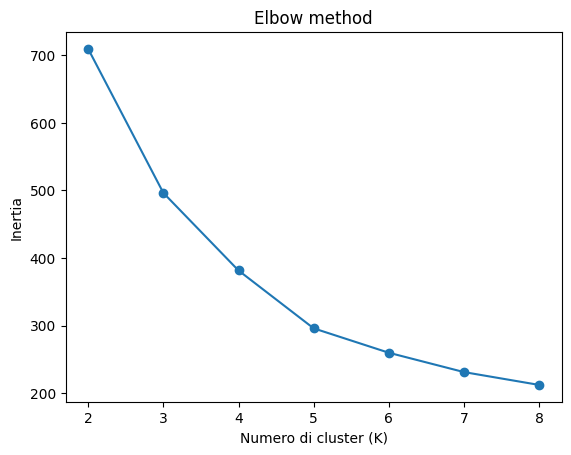

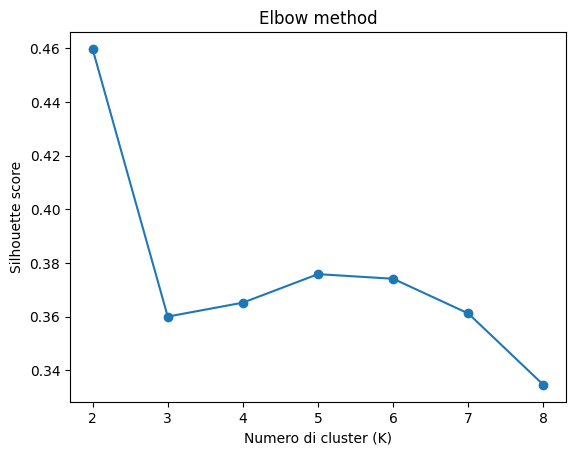

In [76]:
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Numero di cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Numero di cluster (K)")
plt.ylabel("Silhouette score")
plt.title("Elbow method")
plt.show()


In [77]:
# Top cluster
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)

df_clusters["cluster"] = kmeans.fit_predict(X_scaled)

In [78]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

cluster_summary = (
    pd.DataFrame(centroids, columns=features)
    .assign(cluster=range(k))
)

cluster_summary

,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster
0,21.712407,4.725469,16277.838889,2138.962963,29.883519,8.351852,43726.122392,37051.992572,0
1,6.393940,8.433678,21611.630769,3381.923077,4175.505385,1070.615385,44446.745923,25451.213740,1
2,24.588988,1.439451,57145.263492,6268.190476,32.451111,8.111111,43648.159301,35181.511200,2
3,10.937281,8.626440,20414.621212,2951.909091,1445.196667,358.393939,44044.739563,30405.560288,3


In [79]:
df_clusters['country'] = df_clusters['capital'].map(capital_to_country)
df_clusters.head(5)

,capital,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,cluster,country
0,Abuja,26.823444,2.200733,38576.9,4551,0.00,0,43653.205642,33435.919106,2,Nigeria
1,Accra,26.848335,1.460698,20232.3,3841,0.00,0,43638.082460,36090.631905,0,Ghana
2,Addis Ababa,15.732666,1.372649,50712.2,4856,0.00,0,43653.205642,37502.042483,2,Ethiopia
3,Algiers,18.433478,5.715757,18498.8,2412,15.82,6,43878.875057,36932.462103,0,Algeria
4,Alofi,25.278135,1.320144,54899.8,5162,0.00,0,43578.573185,35245.005225,2,Niue


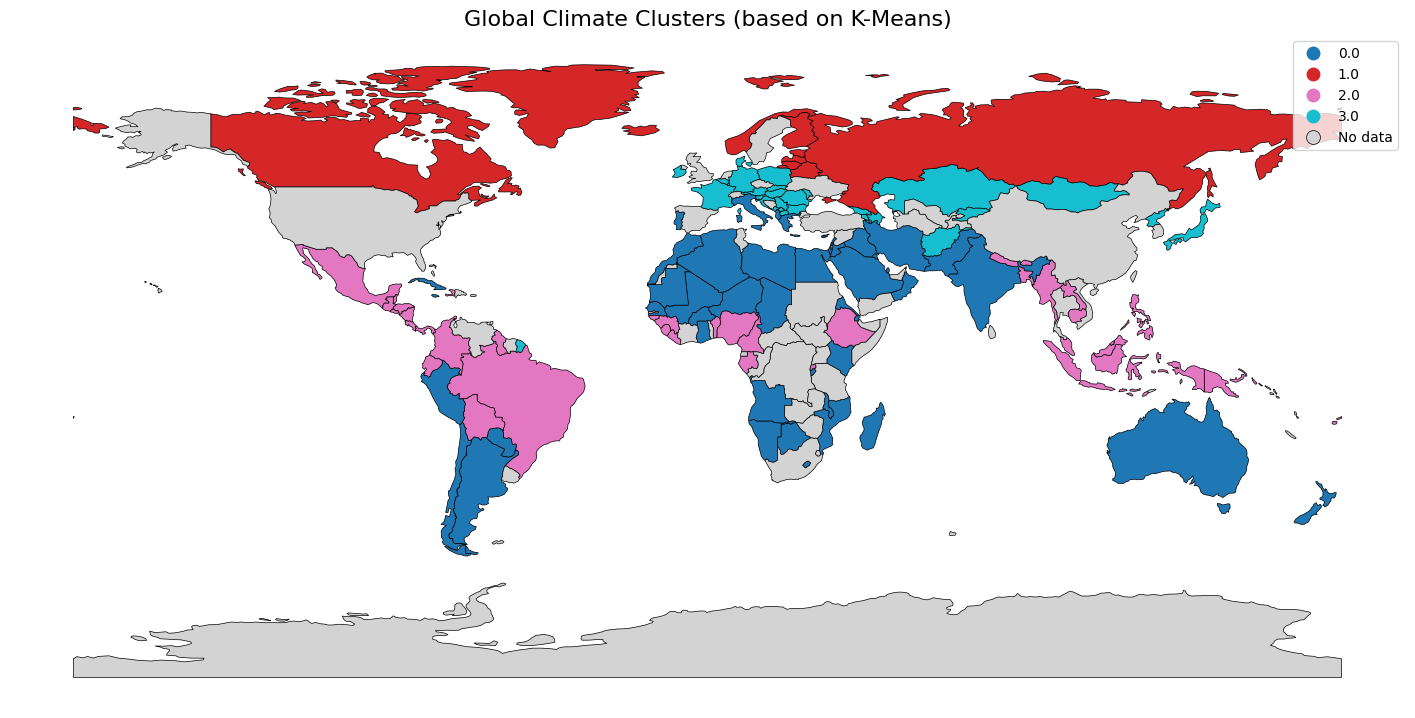

In [84]:
# Temperature difference map (2024 - 1995)
import geopandas as gpd
import matplotlib.pyplot as plt

# World map data
world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)

# Merge temperature change data
world_clusters = world.merge(
    df_clusters,
    how="left",
    left_on="NAME",
    right_on="country"
)

fig, ax = plt.subplots(1, 1, figsize=(18, 9))

world_clusters.plot(
    column="cluster",
    categorical=True,
    cmap="tab10",          # colori discreti
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Global Climate Clusters (based on K-Means)",
    fontsize=16
)

ax.axis("off")
plt.show()